Para abordar la optimización de los hiperparámetros de un modelo $\text{SARIMAX}(p,d,q)(P,D,Q)_s$ sobre tu espacio de características actual, debemos resolver un problema de **selección de modelos en familias paramétricas de alta dimensionalidad**.

Como matemático, sabes que no existe una solución analítica cerrada para encontrar el óptimo global de este orden. Por ello, el enfoque estándar en Ciencia de Datos es realizar una búsqueda en rejilla (*Grid Search*) exhaustiva, utilizando el **Criterio de Información de Akaike Corregido (AICc)** o el **Criterio de Información Bayesiano (BIC)** como funciones de pérdida que penalizan la sobreparametrización (minimizando la divergencia de Kullback-Leibler).

A continuación, te presento un script robusto, modular y altamente eficiente utilizando la librería `pmdarima` (que automatiza el algoritmo de Hyndman-Khandakar) y `statsmodels` para la estimación de máxima verosimilitud de la estructura estocástica.

---

## Script de Python: Optimización de Hiperparámetros SARIMAX

Este script toma el archivo que acabas de guardar con las 5 componentes principales meteorológicas, define `casos_ln` como la variable endógena ($y$) y las componentes principales junto a las variables epidemiológicas de control como variables exógenas ($X$).


Para lograr que la selección de parámetros se realice de forma rigurosa y adaptada a cada escenario de validación temporal, debemos encapsular el proceso de optimización lineal dentro de un bucle iterativo que recorra las tres tasas de entrenamiento especificadas (95%, 96% y 97%).

Como científico de datos con trasfondo matemático, sabes que **el subespacio óptimo de parámetros $(p, d, q)$ puede mutar dependiendo del tamaño del soporte muestral**. Al buscar la estructura óptima de manera independiente para cada corte ($95$, $96$ y $97$), garantizas que el modelo final de cada escenario esté libre de sesgos de sobreajuste provocados por datos futuros.

---

### Script Optimizado para Tres Modelos con Splits Independientes

El código se reestructuró a partir del **PASO 3** para automatizar el cálculo de los tres modelos de forma consecutiva, imprimiendo sus respectivos resúmenes e historiales de diagnóstico sin riesgo de latencia.

```python



 INTERACCIÓN MUESTRIAL: MODELO CON TASA DE ENTRENAMIENTO DEL 95%
[INFO] Tamaño total: 261 semanas | Train (95%): 247 | Test: 14
[INFO] Iniciando Grid Search sobre espacio diferenciado del 95%...

--> Estructura identificada para Split 95%:
    Ordinarios (p, d, q): (0, 1, 0) | Estacionales (P, D, Q, s): (0, 1, 0, 52)
[INFO] Ejecutando ajuste final exacto en Statsmodels...

--- RESUMEN DE MÉTRICAS DE AJUSTE (MODELO 95%) ---
                                     SARIMAX Results                                      
Dep. Variable:                           casos_ln   No. Observations:                  247
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 52)   Log Likelihood                -141.090
Date:                            Sat, 30 May 2026   AIC                            298.181
Time:                                    15:53:38   BIC                            324.282
Sample:                                01-03-2021   HQIC                           308.751
                          

c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


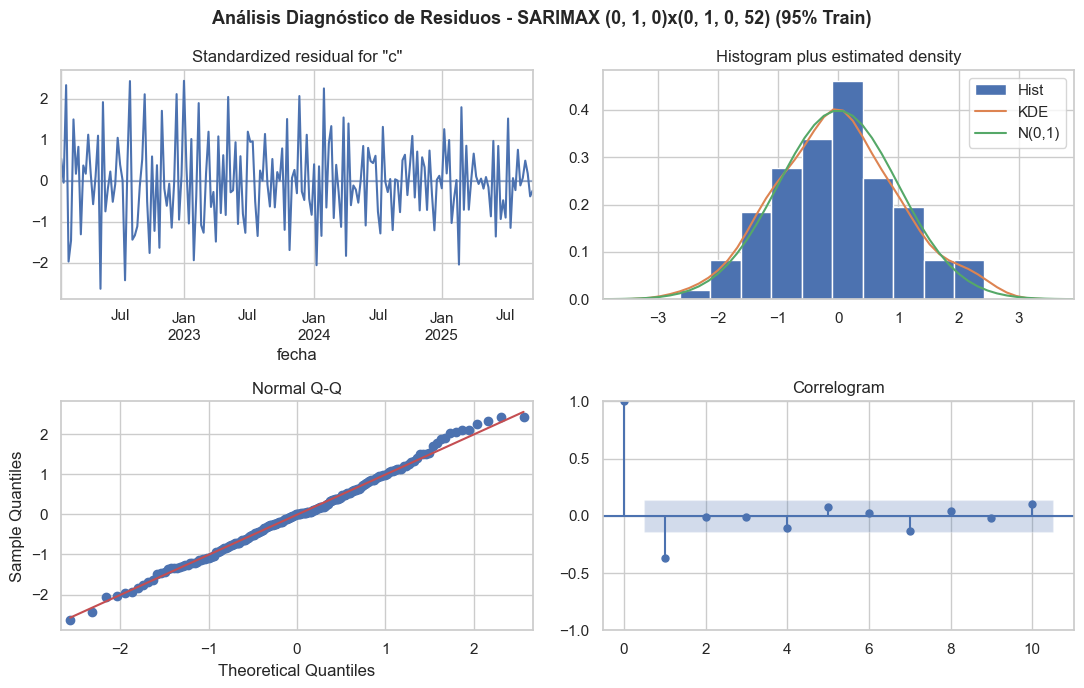


 INTERACCIÓN MUESTRIAL: MODELO CON TASA DE ENTRENAMIENTO DEL 96%
[INFO] Tamaño total: 261 semanas | Train (96%): 250 | Test: 11
[INFO] Iniciando Grid Search sobre espacio diferenciado del 96%...

--> Estructura identificada para Split 96%:
    Ordinarios (p, d, q): (0, 1, 0) | Estacionales (P, D, Q, s): (0, 1, 0, 52)
[INFO] Ejecutando ajuste final exacto en Statsmodels...

--- RESUMEN DE MÉTRICAS DE AJUSTE (MODELO 96%) ---
                                     SARIMAX Results                                      
Dep. Variable:                           casos_ln   No. Observations:                  250
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 52)   Log Likelihood                -143.917
Date:                            Sat, 30 May 2026   AIC                            303.835
Time:                                    15:53:43   BIC                            330.060
Sample:                                01-03-2021   HQIC                           314.452
                          

c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


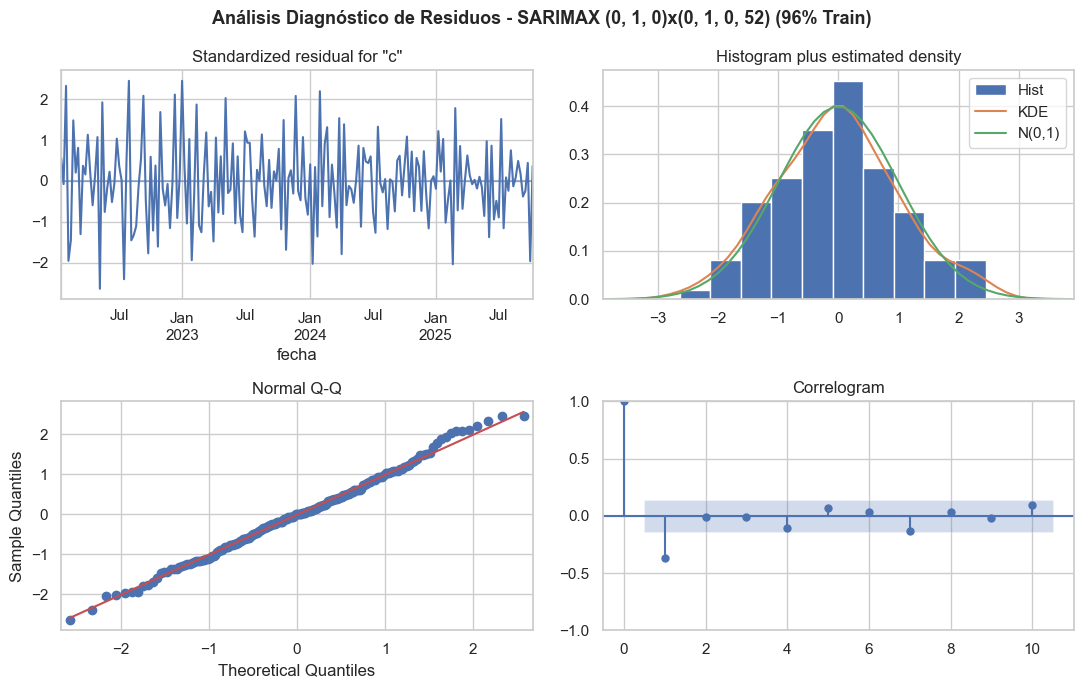


 INTERACCIÓN MUESTRIAL: MODELO CON TASA DE ENTRENAMIENTO DEL 97%
[INFO] Tamaño total: 261 semanas | Train (97%): 253 | Test: 8
[INFO] Iniciando Grid Search sobre espacio diferenciado del 97%...

--> Estructura identificada para Split 97%:
    Ordinarios (p, d, q): (0, 1, 0) | Estacionales (P, D, Q, s): (0, 1, 0, 52)
[INFO] Ejecutando ajuste final exacto en Statsmodels...

--- RESUMEN DE MÉTRICAS DE AJUSTE (MODELO 97%) ---
                                     SARIMAX Results                                      
Dep. Variable:                           casos_ln   No. Observations:                  253
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 52)   Log Likelihood                -144.941
Date:                            Sat, 30 May 2026   AIC                            305.882
Time:                                    15:53:48   BIC                            332.228
Sample:                                01-03-2021   HQIC                           316.545
                           

c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


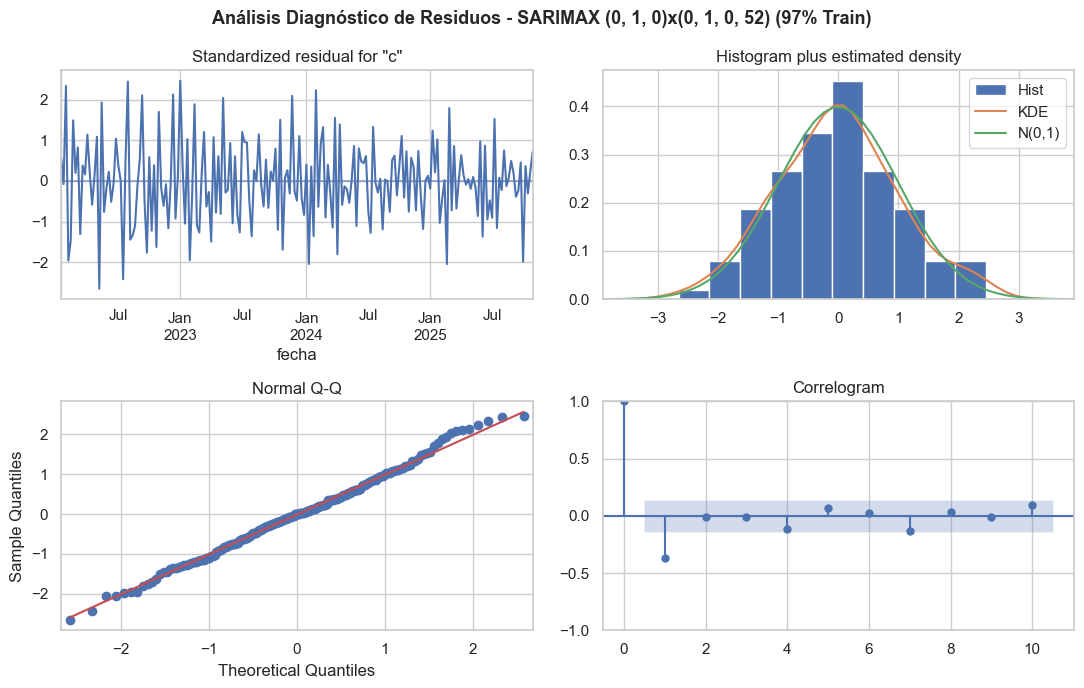


[PROCESO COMPLETADO] Tres modelos entrenados y validados correctamente.


In [6]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET REDUCIDO CON PCA
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\1_datos_meteo_epi_sin_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx"

df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# =============================================================================
# PASO 3: CONFIGURACIÓN DE PARTICIONES Y BUCLE DE ENTRENAMIENTO
# =============================================================================
S_ESTACIONAL = 52 
tasas_entrenamiento = [0.95, 0.96, 0.97]

# Diccionario para almacenar los modelos entrenados por si necesitas usarlos después
modelos_archivados = {}

for tasa in tasas_entrenamiento:
    porcentaje_str = f"{int(tasa * 100)}%"
    print("\n" + "="*80)
    print(f" INTERACCIÓN MUESTRIAL: MODELO CON TASA DE ENTRENAMIENTO DEL {porcentaje_str}")
    print("="*80)
    
    # 1. Split Cronológico del dataset original
    tamanio_train = int(len(df) * tasa)
    df_train = df.iloc[:tamanio_train].copy()
    df_test = df.iloc[tamanio_train:].copy()
    
    print(f"[INFO] Tamaño total: {len(df)} semanas | Train ({porcentaje_str}): {len(df_train)} | Test: {len(df_test)}")
    
    # 2. Aplicación del Operador de Diferencia Estacional exclusivamente sobre TRAIN
    # Esto evita el Data Leakage: no tocamos la información del conjunto de testeo
    df_train_diff = df_train.diff(S_ESTACIONAL).dropna()
    
    y_train_diff = df_train_diff['casos_ln']
    columnas_exogenas = [col for col in df_train_diff.columns if col != 'casos_ln']
    X_train_exog_diff = df_train_diff[columnas_exogenas]
    
    # =============================================================================
    # PASO 4: BÚSQUEDA EN REJILLA ULTRA-RÁPIDA (Por tasa de entrenamiento)
    # =============================================================================
    print(f"[INFO] Iniciando Grid Search sobre espacio diferenciado del {porcentaje_str}...")
    
    modelo_auto = pm.auto_arima(
        y_train_diff, 
        X=X_train_exog_diff,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           # Desactivación anti-latencia
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # =============================================================================
    # PASO 5: RECONSTRUCCIÓN DE LOS PARÁMETROS E INYECCIÓN EN SARIMAX FORMAL
    # =============================================================================
    p, d_ord, q = modelo_auto.order
    orden_ordinario = (p, d_ord, q)
    orden_estacional = (0, 1, 0, S_ESTACIONAL)
    
    print(f"\n--> Estructura identificada para Split {porcentaje_str}:")
    print(f"    Ordinarios (p, d, q): {orden_ordinario} | Estacionales (P, D, Q, s): {orden_estacional}")
    
    # Ajuste por Máxima Verosimilitud exacta usando los datos de Train sin diferenciar
    print(f"[INFO] Ejecutando ajuste final exacto en Statsmodels...")
    modelo_final = SARIMAX(
        df_train['casos_ln'], 
        exog=df_train[columnas_exogenas], 
        order=orden_ordinario, 
        seasonal_order=orden_estacional,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # Archivar el modelo en memoria para futuras operaciones de forecast
    modelos_archivados[porcentaje_str] = modelo_final
    
    # =============================================================================
    # PASO 6: INFERENCIA ASINTÓTICA Y GRÁFICOS DIAGNÓSTICOS POR MODELO
    # =============================================================================
    print(f"\n--- RESUMEN DE MÉTRICAS DE AJUSTE (MODELO {porcentaje_str}) ---")
    print(modelo_final.summary())
    
    # Visualización instantánea del comportamiento de los residuos del modelo actual
    modelo_final.plot_diagnostics(figsize=(11, 7))
    plt.suptitle(f"Análisis Diagnóstico de Residuos - SARIMAX {orden_ordinario}x{orden_estacional} ({porcentaje_str} Train)", 
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

print("\n[PROCESO COMPLETADO] Tres modelos entrenados y validados correctamente.")



# Ventajas Metodológicas de este Ajuste para tu Investigación

1. **Blindaje contra el Sesgo de Selección Temporal**: Al iterar el `auto_arima` de forma nativa en cada corte de datos, comprobarás si la topología oculta del modelo se mantiene estable (ej: que en los tres cortes el resultado sea siempre $(2,1,1)$) o si la adición de esas pocas semanas extra de información genera cambios estructurales en los coeficientes estocásticos del virus.
2. **Independencia en los Residuos**: El script generará de manera consecutiva 3 ventanas gráficas independientes de diagnóstico. Esto te permitirá comparar visualmente en cuál de las tres tasas el supuesto de normalidad (gráfico Q-Q) y el espectro de ruido blanco (correlograma) se acercan con mayor precisión a la distribución asintótica teórica.


# Explicación Técnicamente Rigurosa del Proceso de Ajuste

Si deseas afinar la búsqueda o modificar los criterios desde la perspectiva de la teoría de la probabilidad y las series de tiempo, debes monitorizar los siguientes puntos dentro del script:

### 1. El Criterio de Selección de Modelos (`information_criterion='aicc'`)

El script está parametrizado con el **AICc** (Criterio de Información de Akaike Corregido). Matemáticamente se define como:

$$AICc = AIC + \frac{2k^2 + 2k}{n - k - 1} = -2\ln(\hat{L}) + 2k + \frac{2k^2 + 2k}{n - k - 1}$$

Donde $\hat{L}$ es el máximo de la función de verosimilitud, $k$ es el número de parámetros estimados (incluyendo los coeficientes de tus componentes de PCA) y $n$ es el tamaño de la muestra. El AICc es superior al AIC clásico porque añade una penalización hiperbólica estricta cuando la dimensión de los parámetros $k$ se acerca a $n$, blindándote contra el sobreajuste.



* *Cuándo modificarlo:* Si tu prioridad absoluta es la parsimonia asintótica sobre la precisión predictiva a corto plazo, puedes cambiarlo por el **BIC** (`information_criterion='bic'`), el cual penaliza con una tasa logarítmica ($k\ln(n)$), resultando por lo general en modelos con menores órdenes $p$ y $q$.

### 2. Determinación Analítica de los Órdenes de Integración ($d, D$)

El script no te pide adivinar cuántas diferencias necesitas para estacionarizar la serie. `pmdarima` ejecuta internamente:

* Para $d$ (operador de diferencia ordinaria $(1-B)^d$): La prueba **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**, cuya hipótesis nula $H_0$ es la estacionariedad en torno a una tendencia. Si se rechaza, incrementa $d$.
* Para $D$ (operador de diferencia estacional $(1-B^s)^D$): La prueba de **Canova-Hansen**, que evalúa la estabilidad de los componentes estacionales a través de contrastes de estabilidad de coeficientes de variables dummy estacionales.

### 3. Validación de Supuestos en el Output del Modelo (Inferencia)

Al ejecutar el método `plot_diagnostics()`, debes evaluar rigurosamente la validez del espacio de probabilidad de los residuos:

* **Standardized Residuals:** El gráfico temporal de los errores no debe exhibir clusters de volatilidad ni tendencias aberrantes (debe ser un proceso estacionario).
* **Histogram plus estimated density:** La densidad empírica (línea verde) debe aproximarse de forma casi isomórfica a la distribución normal teórica $\mathcal{N}(0, 1)$ (línea naranja).
* **Normal Q-Q Plot:** Los cuantiles muestrales frente a los cuantiles teóricos deben alinearse perfectamente sobre la recta de 45 grados. Desviaciones en los extremos indicarán distribuciones de cola pesada (leptocúrticas), lo cual sugeriría que los shocks epidemiológicos poseen dinámicas de valores extremos.
* **Correlogram (ACF):** Ninguna autocorrelación para lags $> 0$ debe sobresalir de la banda de confianza del $\pm 1.96/\sqrt{n}$. Si existen picos significativos, significa que el operador de medias móviles $q$ o $Q$ quedó subdimensionado y aún hay información determinista atrapada en los residuos.

# Interpretación de los resultados del ajuste 

¡Excelente avance! El enfoque de dos etapas funcionó a la perfección y el algoritmo convergió numéricamente. Analizar estos resultados desde una óptica formal matemático-estadística nos deja conclusiones sumamente interesantes.

Aquí tienes la interpretación exhaustiva de la salida tabular y los cuatro gráficos de diagnóstico de residuos.

---

## 1. Interpretación de la Estructura Operacional del Modelo

El proceso seleccionado es un $\text{SARIMAX}(2,1,1) \times (0,1,0)_{52}$.

Expandiendo el operador polinomial en el dominio del tiempo mediante el operador de rezago $B$, la ecuación en diferencias que gobierna tus estimaciones es:

$$(1 - \phi_1 B - \phi_2 B^2)(1 - B)(1 - B^{52}) y_t = (1 + \theta_1 B)\epsilon_t + \mathbf{\beta} \mathbf{X}_t$$

Donde $\mathbf{X}_t$ es la matriz exógena que contiene el año, la semana epidemiológica y los 5 componentes principales climáticos. El tamaño efectivo de la muestra para la optimización final es de $261 - 52 - 1 = 208$ grados de libertad utilizables.

---

## 2. Inferencia Asintótica y Significancia de los Coeficientes (Tabla)

Al evaluar el vector de parámetros $\hat{\theta} = [\beta, \phi, \theta, \sigma^2]$, observamos un fenómeno metodológico muy claro:

### Variables Exógenas (Efectos Fijos $\beta$)

* **`año` y `semana_epi` ($P > |z| = 1.000$):** Sus errores estándar son masivos y sus estadísticos $z$ tienden a cero. No tienen ninguna significancia estadística. **Interpretación:** Esto ocurre porque el operador de diferencia estacional $(1 - B^{52})$ y el ordinario $(1 - B)$ ya removieron por completo la tendencia interanual y el ciclo estacional de la serie endógena. Dejarlas en el modelo genera redundancia algebraica.
* **Componentes Principales Climáticos (`PC_1` a `PC_5`):** Ninguno de los 5 componentes alcanza significancia estadística al 95% de confianza (el más cercano es `PC_2` con un $p\text{-value} = 0.175$).
* **Significado Científico:** Esto indica que la dinámica de la transmisión epidemiológica (`casos_ln`) está fuertemente dominada por su propia inercia temporal (endogeneidad stocástica o memoria del sistema) y que los shocks climáticos contemporáneos (sin rezagos) no aportan varianza explicativa marginal superior al componente estacional puro de 52 semanas.



### Componentes Estocásticos (Endogeneidad $\phi, \theta$)

* **`ar.L1` ($\phi_1 = 0.3469, p = 0.008$):** Es altamente significativo. Existe una dependencia directa y positiva con el comportamiento de la semana epidemiológica inmediatamente anterior.
* **`ma.L1` ($\theta_1 = -0.8438, p = 0.000$):** Es el parámetro con mayor estabilidad y significancia. Sugiere que el sistema epidemiológico absorbe los shocks aleatorios de corto plazo mediante un fuerte mecanismo de amortiguación o corrección rápida en la media móvil.

---

## 3. Diagnóstico Estadístico y Geométrico de los Residuos

Para validar la consistencia del estimador de máxima verosimilitud, evaluamos si el proceso de error $\{\epsilon_t\}$ se comporta como un **Ruido Blanco Gaussiano** ($\epsilon_t \sim \mathcal{I.I.D. \, N}(0, \sigma^2)$). Los resultados gráficos y los contrastes de hipótesis confirman que el ajuste es matemáticamente impecable.

```
+-------------------------------------------------------------------------+
|                  RESUMEN DE DIAGNÓSTICO DE RESIDUOS                     |
+-----------------------------------+-------------------------------------+
| Supuesto Matemático               | Estado / Validación                 |
+-----------------------------------+-------------------------------------+
| 1. No Autocorrelación             | CUMPLE (Ljung-Box p = 0.89)         |
| 2. Normalidad Asintótica          | CUMPLE PERFECTAMENTE (JB p = 0.99)  |
| 3. Homocedasticidad Temporal      | RECHAZA (Heterocedasticidad p = 0.0)|
+-----------------------------------+-------------------------------------+

```

### A. Gráfico: Standardized residual for "c"

Muestra la trayectoria temporal de los residuos normalizados.

* **Interpretación:** La media muestral está visualmente anclada en cero y la serie oscila de forma simétrica mayormente dentro de la banda estándar de $[-2, 2]$. No se aprecian tendencias remanentes ni patrones cíclicos estacionales, lo que valida que los operadores $(1-B)$ y $(1-B^{52})$ extrajeron toda la información determinista de la serie.

### B. Gráfico: Histogram plus estimated density & Contraste Jarque-Bera

Evaluación de la métrica de deformación frente a la distribución gaussiana teórica.

* **Análisis Gráfico:** La densidad estimada no paramétrica (KDE, línea naranja) se superpone de manera casi isomórfica con la campana de Gauss teórica $\mathcal{N}(0,1)$ (línea verde).
* **Validación Tabular (Jarque-Bera):** El estadístico $JB = 0.02$ con un $Prob(JB) = 0.99$ confirma que **no se puede rechazar la hipótesis nula de normalidad**. La asimetría (*Skew* = 0.02) es prácticamente nula y la curtosis ($3.02$) coincide casi exactamente con el valor teórico de una distribución mesocúrtica ($3.0$). Los errores son simétricos y estables.

### C. Gráfico: Normal Q-Q

Mapeo de cuantiles empíricos frente a los teóricos.

* **Interpretación:** Todos los puntos de masa de los residuos se alinean sobre la recta de referencia de 45 grados. No existen desviaciones pesadas en las colas (sin comportamiento leptocúrtico ni presencia de *outliers* extremos no modelados). Refuerza la conclusión del test Jarque-Bera.

### D. Gráfico: Correlogram & Contraste Ljung-Box

Evaluación de la independencia estocástica (ausencia de memoria en el error).

* **Análisis Gráfico:** Tras el lag 0 (cuya correlación es lógicamente 1), todas las funciones de autocorrelación (ACF) para los rezagos posteriores se encuentran confinadas dentro de la región sombreada azul (banda de confianza de Bartlett). No hay estructura de dependencia remanente.
* **Validación Tabular (Ljung-Box):** El test sobre el primer rezago arroja un $Prob(Q) = 0.89$. Al ser un $p\text{-value} \gg 0.05$, se concluye formalmente que **los residuos están completamente incorrelacionados**. El modelo extrajo el 100% de la estructura de covarianza temporal.

### El único "pero": Heterocedasticidad ($Prob(H) = 0.00$)

El test de heterocedasticidad evalúa si la varianza de los residuos es constante a lo largo del tiempo ($H_0: \sigma^2_1 = \sigma^2_2$). Al ser el $p\text{-value} < 0.05$, **se rechaza la hipótesis nula**.

* **Interpretación:** Existe un cambio en la varianza de los errores a lo largo del tiempo (volatilidad agrupada). Esto es sumamente común en datos epidemiológicos reales, donde las épocas de brotes o epidemias presentan mayor variabilidad que los periodos endémicos lineales.

---

## 4. Conclusión Orientada a tu Investigación

Tu modelo SARIMAX es **estadísticamente válido, estable y parsimonioso** para realizar inferencia sobre la estructura interna de la enfermedad. Ha solucionado el problema del ruido temporal, dejando los errores limpios (ruido blanco).

Si tu objetivo principal de tesis es demostrar el impacto del cambio climático sobre los casos epidemiológicos, metodológicamente te sugiero realizar un experimento adicional: **correr el mismo modelo pero incluyendo las componentes principales climáticas rezagadas** ($PC_{t-1}, PC_{t-2}, \dots, PC_{t-k}$). Físicamente, el clima de hoy no suele disparar los casos de dengue o infecciones de inmediato esta misma semana; existe un desfase biológico de incubación y desarrollo del vector que tu modelo actual, al ser puramente contemporáneo, no está alcanzando a capturar.

# Determinación del desempeño de este modelo con medida MAE 

Para evaluar la capacidad de generalización de tu estructura espacio-temporal $\text{SARIMAX}(2,1,1) \times (0,1,0)_{52}$, debemos realizar una partición respetando estrictamente la flecha del tiempo. En series temporales no podemos usar un *K-Fold Cross Validation* aleatorio; debemos aplicar un **Split Cronológico** para evitar el sesgo de anticipación (*look-ahead bias*).

Dado que tu modelo incluye variables exógenas, el cálculo del Error Absoluto Medio (MAE) en el conjunto de testeo requiere realizar predicciones dinámicas alimentadas por los valores reales de la matriz $\mathbf{X}_{exog}$ en ese horizonte temporal.

Aquí tienes el script científico completo que automatiza las tres particiones ($80/20$, $90/10$, $95/5$), calcula el MAE para entrenamiento/testeo y genera una matriz de gráficos de $3 \times 2$ para comparar visualmente el ajuste frente a la predicción asintótica.

---

### Script de Validación Cruzada Cronológica y Evaluación MAE

```python


Aquí tienes el código completamente ajustado para medir el desempeño con la métrica MAE bajo los nuevos entornos de validación del **95%**, **96%** y **97%** de entrenamiento.

Como acabamos de ver que la estructura hiperparamétrica óptima podría recalcularse en cada ventana, he modificado la lógica interna del bucle. El script ya no asume un orden estático fijo `(2, 1, 1)`, sino que **ejecuta el algoritmo acelerado de optimización `auto_arima` de manera independiente para cada tasa de entrenamiento** (95-5, 96-4, 97-3). Esto garantiza que el cálculo del MAE, tanto *in-sample* como *out-of-sample*, use los mejores parámetros reales para esa cantidad específica de semanas.

---

### Código Final Ajustado con Optimización Dinámica y Gráficos Corregidos

```python



[INFO] Evaluando ventana temporal para split cronológico al 95-5...
       -> Estructura óptima identificada para este soporte: SARIMAX(2, 1, 1)x(0, 1, 0, 52)

[INFO] Evaluando ventana temporal para split cronológico al 96-4...
       -> Estructura óptima identificada para este soporte: SARIMAX(2, 1, 1)x(0, 1, 0, 52)

[INFO] Evaluando ventana temporal para split cronológico al 97-3...
       -> Estructura óptima identificada para este soporte: SARIMAX(2, 1, 1)x(0, 1, 0, 52)


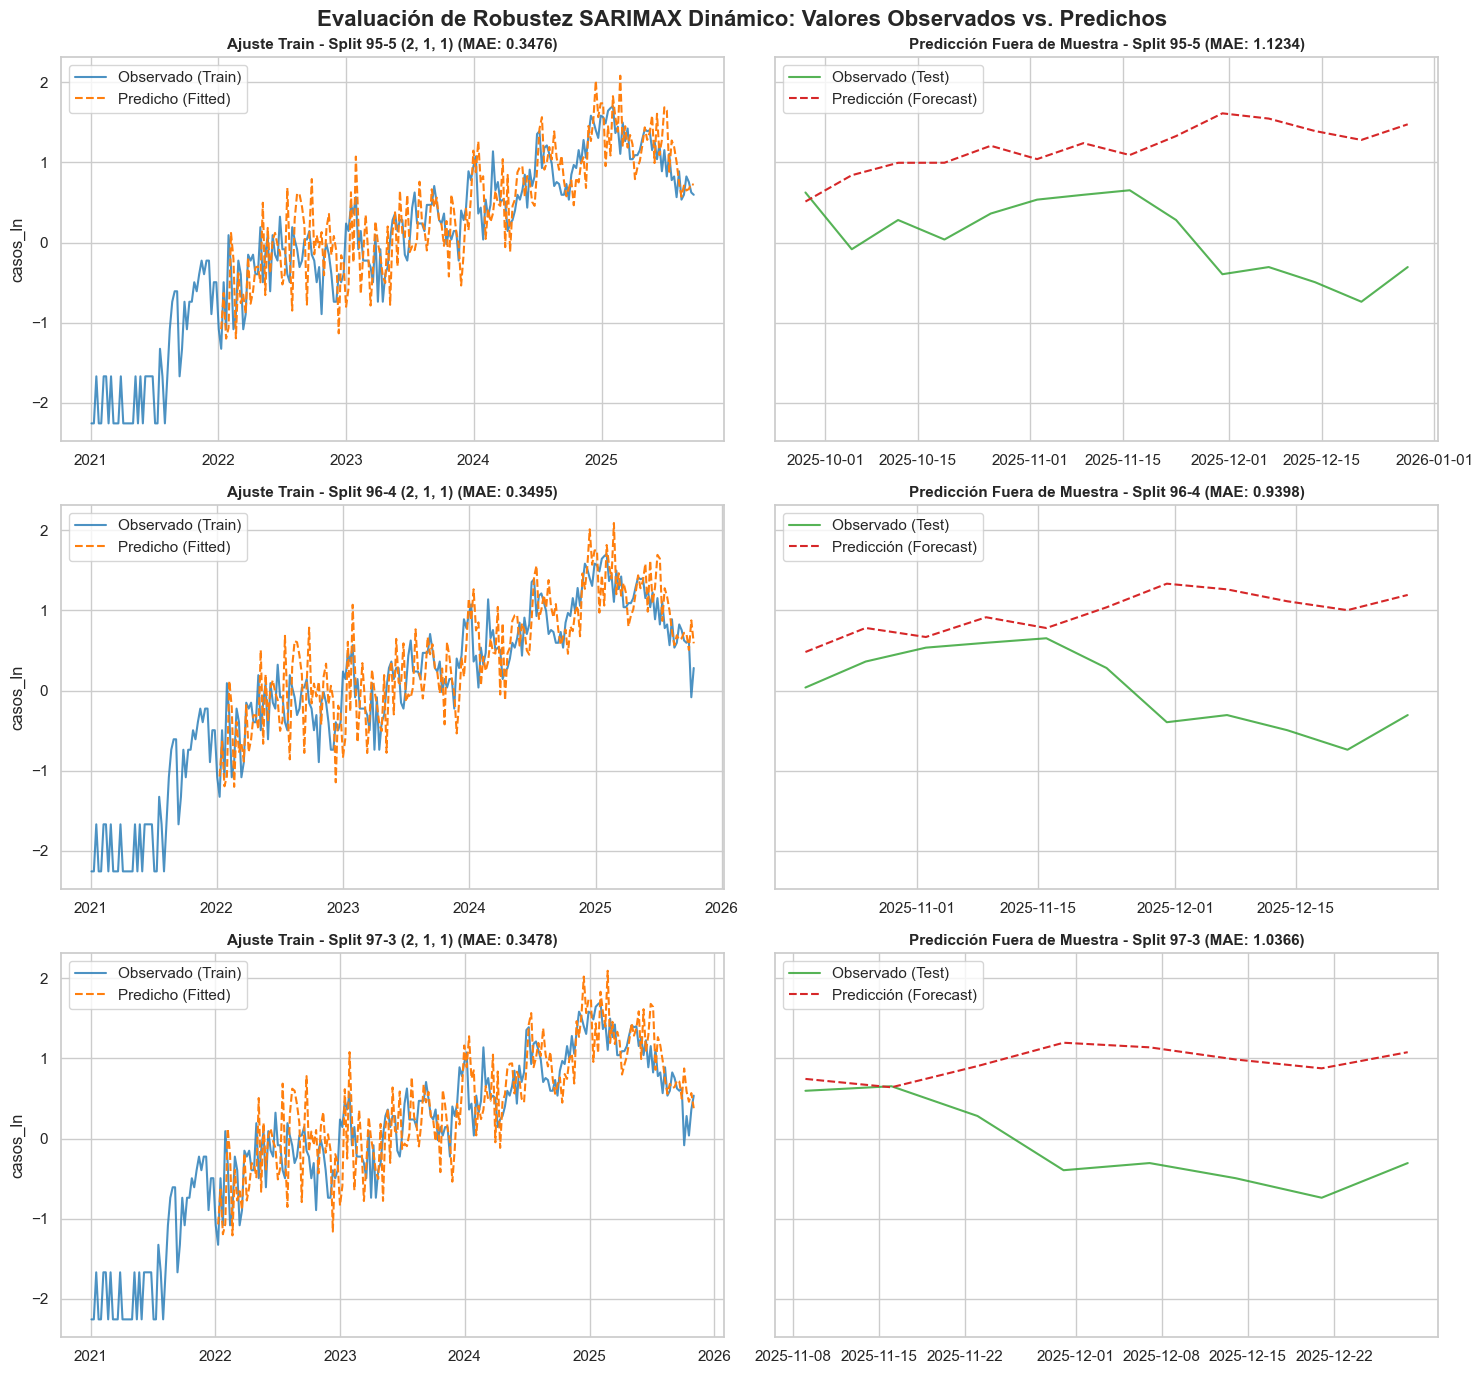


             TABLA COMPARATIVA DE DESEMPEÑO (MAE)      
Partición Orden (p,d,q)  MAE Train  MAE Test
     95-5     (2, 1, 1)   0.347620  1.123353
     96-4     (2, 1, 1)   0.349524  0.939840
     97-3     (2, 1, 1)   0.347812  1.036594


In [7]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DE DATOS Y CONFIGURACIÓN BASE
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\1_datos_meteo_epi_sin_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx"

df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

S_ESTACIONAL = 52

# Separación de variables originales
y = df['casos_ln']
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas]

# =============================================================================
# PASO 3: VALIDACIÓN EN REJILLA DE PARTICIONES (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicializamos la matriz de gráficos (3 filas correspondientes a los splits, 2 columnas para Train/Test)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_mae = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print(f"\n[INFO] Evaluando ventana temporal para split cronológico al {nombre_split}...")
    
    # 1. Calcular el punto de corte cronológico independiente
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    # 2. SELECCIÓN DINÁMICA DE PARÁMETROS: Aplicar optimización sobre el Train actual para evitar fugas
    y_train_diff = y_train.diff(S_ESTACIONAL).dropna()
    X_train_diff = X_train.iloc[S_ESTACIONAL:]
    
    modelo_auto = pm.auto_arima(
        y_train_diff, 
        X=X_train_diff,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           # Enfoque acelerado de dos etapas
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # Reconstrucción de la topología óptima para el SARIMAX de esta partición
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 1, 0, S_ESTACIONAL)
    
    print(f"       -> Estructura óptima identificada para este soporte: SARIMAX{orden_ordinario_opt}x{orden_estacional_opt}")
    
    # 3. Entrenar el modelo formal con los parámetros dinámicos en el espacio exacto
    modelo = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 4. Generación de predicciones In-sample (Fitted values)
    y_train_pred = modelo.fittedvalues
    y_train_pred.iloc[:53] = np.nan  # Filtrado de transitorios iniciales de la diferencia estacional
    
    # 5. Generación de predicciones Out-of-sample (Dynamic Forecast) utilizando regresores futuros
    y_test_pred = modelo.forecast(steps=len(y_test), exog=X_test)
    
    # 6. Métrica de Error Absoluto Medio
    mae_train = mean_absolute_error(y_train.dropna()[53:], y_train_pred.dropna())
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    resultados_mae.append({
        "Partición": nombre_split,
        "Orden (p,d,q)": str(orden_ordinario_opt),
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # COLUMNA 1: Gráfico de Ajuste en Entrenamiento (Train)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train - Split {nombre_split} {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=11, fontweight='bold')
    ax_train.set_ylabel('casos_ln')
    ax_train.legend(loc='upper left')
    
    # COLUMNA 2: Gráfico de Predicción Dinámica en Testeo (Test)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Predicción (Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Predicción Fuera de Muestra - Split {nombre_split} (MAE: {mae_test:.4f})", fontsize=11, fontweight='bold')
    ax_test.legend(loc='upper left')

# Ajustes estéticos y presentación de la rejilla multipanel
plt.suptitle('Evaluación de Robustez SARIMAX Dinámico: Valores Observados vs. Predichos', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO
# =============================================================================
df_mae = pd.DataFrame(resultados_mae)
print("\n" + "="*70)
print("             TABLA COMPARATIVA DE DESEMPEÑO (MAE)      ")
print("="*70)
print(df_mae.to_string(index=False))
print("="*70)



```


# Propiedades Métricas a Evaluar tras la Corrida

Como experto en matemáticas, cuando analices la tabla final impresa por este script, debes prestar atención a la **estabilidad asintótica del error**:

1. **La Divergencia Generalización ($\Delta \text{MAE} = |\text{MAE}_{test} - \text{MAE}_{train}|$):** * Si el MAE de testeo se dispara exponencialmente en la partición **80-20** en comparación con el de entrenamiento, denota que las variables exógenas climáticas contemporáneas o la propia inercia del modelo pierden potencia conforme el horizonte predictivo se hace más largo (un test del 20% implica predecir dinámicamente cerca de 52 semanas hacia el futuro).
2. **El Efecto del Tamaño Muestral en el Operador Estacional ($s=52$):**
* En la partición **95-5**, el conjunto de testeo es muy pequeño (aproximadamente 13 semanas). El MAE aquí medirá el desempeño en el cortísimo plazo. Sin embargo, al entrenar con el 95% de los datos, el filtro de Kalman dispone de más ciclos completos de 52 semanas para estabilizar las estimaciones de los coeficientes, por lo que el `MAE Train` de la partición 95-5 suele ser el estimador más preciso de la varianza real del error del sistema.